In [1]:
import pandas as pd

df = pd.read_csv("17_play-action-vs-run.csv")

# Restrict to weeks 1-6
wk = df[df["week"].between(1, 6)]

# (1) Overall observed proportion of playActionPass (1 vs 0)
overall_props = wk["playActionPass"].value_counts(normalize=True).sort_index()
print("Overall proportion of playActionPass (weeks 1-6):")
print(overall_props)
print()

# (2) Proportion within each (receiverAlignment, offenseFormation) box
grid_counts = (
    wk.groupby(["receiverAlignment", "offenseFormation", "playActionPass"])
    .size()
    .unstack("playActionPass", fill_value=0)
)

grid_props = grid_counts.div(grid_counts.sum(axis=1), axis=0)
grid_props["n"] = grid_counts.sum(axis=1)

print("Proportion of playActionPass within each receiverAlignment x offenseFormation box (with n):")
print(grid_props)

Overall proportion of playActionPass (weeks 1-6):
playActionPass
0    0.708559
1    0.291441
Name: proportion, dtype: float64

Proportion of playActionPass within each receiverAlignment x offenseFormation box (with n):
playActionPass                             0         1     n
receiverAlignment offenseFormation                          
1x0               I_FORM            1.000000  0.000000     1
                  JUMBO             0.750000  0.250000     4
                  SHOTGUN           1.000000  0.000000     1
1x1               I_FORM            0.771930  0.228070    57
                  JUMBO             0.960000  0.040000    25
                  PISTOL            0.555556  0.444444    18
                  SHOTGUN           0.833333  0.166667     6
                  WILDCAT           1.000000  0.000000     1
2x0               I_FORM            0.880000  0.120000    25
                  JUMBO             0.500000  0.500000     6
2x1               I_FORM            0.735343  0.2

In [2]:
import numpy as np
import pandas as pd
import patsy
import statsmodels.api as sm

df = pd.read_csv("17_play-action-vs-run.csv")

train = df[df["week"].between(1, 6)].copy()
val = df[df["week"] == 7].copy()

formula = (
    "playActionPass ~ "
    "C(quarter) + C(down) + "
    "yardsToEndzone + yardsToGo + "
    "gameClockSeconds * scoreDifferential + "
    "C(offenseFormation) * C(receiverAlignment) + "
    "offenseWidth + "
    "defenseWidth + "
    "defenseDepth + "
    "offenseDepth + "
    "boxDefenders"
)

# Build design matrices; reuse train's design_info to build val matrix consistently
y_train, X_train = patsy.dmatrices(formula, data=train, return_type="dataframe")
X_val = patsy.dmatrix(X_train.design_info, data=val, return_type="dataframe")
y_val = val["playActionPass"].values

# Identify interaction columns (contain ":" -> these are the only ones penalized)
interaction_cols = [c for c in X_train.columns if ":" in c]
print("Penalized (interaction) columns:", interaction_cols)

def fit_with_alpha(alpha_val):
    alpha_vec = np.array([alpha_val if c in interaction_cols else 0.0 for c in X_train.columns])
    model = sm.Logit(y_train, X_train)
    result = model.fit_regularized(
        method="l1",
        alpha=alpha_vec,
        maxiter=1000,
        trim_mode="auto",
        disp=False,
    )
    return result

def log_loss(y_true, p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))

alpha_grid = [1, 2, 3, 4, 5]
scores = {}

for a in alpha_grid:
    result = fit_with_alpha(a)
    p_val = result.predict(X_val)
    loss = log_loss(y_val, p_val.values)
    scores[a] = loss
    print(f"alpha={a}: validation log-loss={loss:.5f}")

best_alpha = min(scores, key=scores.get)
print(f"\nBest alpha (lowest Week 7 log-loss): {best_alpha}")

final_result = fit_with_alpha(best_alpha)
print(final_result.summary())



Penalized (interaction) columns: ['C(offenseFormation)[T.I_FORM]:C(receiverAlignment)[T.1x1]', 'C(offenseFormation)[T.JUMBO]:C(receiverAlignment)[T.1x1]', 'C(offenseFormation)[T.PISTOL]:C(receiverAlignment)[T.1x1]', 'C(offenseFormation)[T.SHOTGUN]:C(receiverAlignment)[T.1x1]', 'C(offenseFormation)[T.SINGLEBACK]:C(receiverAlignment)[T.1x1]', 'C(offenseFormation)[T.UNKNOWN]:C(receiverAlignment)[T.1x1]', 'C(offenseFormation)[T.WILDCAT]:C(receiverAlignment)[T.1x1]', 'C(offenseFormation)[T.I_FORM]:C(receiverAlignment)[T.2x0]', 'C(offenseFormation)[T.JUMBO]:C(receiverAlignment)[T.2x0]', 'C(offenseFormation)[T.PISTOL]:C(receiverAlignment)[T.2x0]', 'C(offenseFormation)[T.SHOTGUN]:C(receiverAlignment)[T.2x0]', 'C(offenseFormation)[T.SINGLEBACK]:C(receiverAlignment)[T.2x0]', 'C(offenseFormation)[T.UNKNOWN]:C(receiverAlignment)[T.2x0]', 'C(offenseFormation)[T.WILDCAT]:C(receiverAlignment)[T.2x0]', 'C(offenseFormation)[T.I_FORM]:C(receiverAlignment)[T.2x1]', 'C(offenseFormation)[T.JUMBO]:C(receive

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


alpha=1: validation log-loss=0.58415
alpha=2: validation log-loss=0.58406
alpha=3: validation log-loss=0.58352
alpha=4: validation log-loss=0.58359
alpha=5: validation log-loss=0.58336

Best alpha (lowest Week 7 log-loss): 5
                           Logit Regression Results                           
Dep. Variable:         playActionPass   No. Observations:                 5912
Model:                          Logit   Df Residuals:                     5875
Method:                           MLE   Df Model:                           36
Date:                Wed, 24 Jun 2026   Pseudo R-squ.:                 0.04283
Time:                        11:42:10   Log-Likelihood:                -3414.7
converged:                       True   LL-Null:                       -3567.5
Covariance Type:            nonrobust   LLR p-value:                 1.878e-44
                                                                        coef    std err          z      P>|z|      [0.025      0.975]
---------

In [3]:
#Log loss on the logistic regression

week6 = df[df["week"] == 6].copy()

X_week6 = patsy.dmatrix(X_train.design_info, data=week6, return_type="dataframe")
y_week6 = week6["playActionPass"].values

p_week6 = final_result.predict(X_week6)
week6_log_loss = log_loss(y_week6, p_week6.values)

print(f"Week 6 log-loss (best_alpha={best_alpha}): {week6_log_loss:.5f}")

Week 6 log-loss (best_alpha=5): 0.57151


In [5]:
import numpy as np
import pandas as pd
import patsy
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("17_play-action-vs-run.csv")

train = df[df["week"].between(1, 6)].copy()
val = df[df["week"] == 7].copy()

formula_rhs = (
    "C(quarter) + C(down) + "
    "yardsToEndzone + yardsToGo + "
    "gameClockSeconds * scoreDifferential + "
    "C(offenseFormation) * C(receiverAlignment) + "
    "offenseWidth + "
    "defenseWidth + "
    "defenseDepth + "
    "offenseDepth + "
    "boxDefenders"
)

y_train = train["playActionPass"].values
y_val = val["playActionPass"].values

X_train = patsy.dmatrix(formula_rhs, data=train, return_type="dataframe")
X_val = patsy.dmatrix(X_train.design_info, data=val, return_type="dataframe")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.values)
X_val_scaled = scaler.transform(X_val.values)

def log_loss(y_true, p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))

H_grid = [2, 4, 6, 8]
alpha_grid = [0.001, 0.01, 0.02, 0.05, 0.1, 1]

results = []
for H in H_grid:
    for wd in alpha_grid:
        clf = MLPClassifier(
            hidden_layer_sizes=(H,),
            alpha=wd,
            activation="relu",
            solver="lbfgs",
            max_iter=5000,
            random_state=0,
        )
        clf.fit(X_train_scaled, y_train)
        p_val = clf.predict_proba(X_val_scaled)[:, 1]
        loss = log_loss(y_val, p_val)
        results.append({"H": H, "weight_decay": wd, "val_log_loss": loss})

results_df = pd.DataFrame(results).sort_values(["H", "weight_decay"]).reset_index(drop=True)
print("Validation grid (Week 7 log-loss):")
print(results_df.pivot(index="H", columns="weight_decay", values="val_log_loss"))

best_row = results_df.loc[results_df["val_log_loss"].idxmin()]
best_H = int(best_row["H"])
best_wd = best_row["weight_decay"]
best_loss = best_row["val_log_loss"]

print(f"\nSelected hidden units (H): {best_H}")
print(f"Selected weight decay: {best_wd}")
print(f"Validation log-loss at selected hyperparameters: {best_loss:.5f}")

Validation grid (Week 7 log-loss):
weight_decay     0.001     0.010     0.020     0.050     0.100     1.000
H                                                                       
2             0.606040  0.608754  0.607913  0.605487  0.606351  0.582509
4             0.580767  0.579837  0.587723  0.579127  0.581947  0.578309
6             0.587971  0.590762  0.590674  0.593694  0.594565  0.584286
8             0.612005  0.603699  0.602865  0.603882  0.611990  0.590616

Selected hidden units (H): 4
Selected weight decay: 1.0
Validation log-loss at selected hyperparameters: 0.57831


In [6]:
#XGBoost

import numpy as np
import pandas as pd
import xgboost as xgb

df = pd.read_csv("17_play-action-vs-run.csv")

train = df[df["week"].between(1, 6)].copy()
val = df[df["week"] == 7].copy()

# Decoupled predictors: raw columns, categoricals one-hot encoded separately (no products)
feature_cols = [
    "quarter", "down",                      # (A), (B) -- treated as categorical
    "yardsToEndzone", "yardsToGo",          # (C), (D)
    "gameClockSeconds", "scoreDifferential",  # (E) decoupled
    "offenseFormation", "receiverAlignment",  # (F) decoupled
    "offenseWidth", "defenseWidth",         # (G), (H)
    "defenseDepth", "offenseDepth",         # (I), (J)
    "boxDefenders",                         # (K)
]

categorical_cols = ["quarter", "down", "offenseFormation", "receiverAlignment"]

def build_X(data, ref_columns=None):
    X = pd.get_dummies(data[feature_cols], columns=categorical_cols)
    if ref_columns is not None:
        X = X.reindex(columns=ref_columns, fill_value=0)
    return X

X_train = build_X(train)
X_val = build_X(val, ref_columns=X_train.columns)

y_train = train["playActionPass"].values
y_val = val["playActionPass"].values

n_train = len(y_train)

def log_loss(y_true, p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))

depth_grid = [2, 4, 6, 8, 10]
lr_grid = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4]
mcw_pct_grid = [0.01, 0.02, 0.05, 0.10]
rounds_grid = [2, 3, 4, 5]

results = []
for depth in depth_grid:
    for lr in lr_grid:
        for mcw_pct in mcw_pct_grid:
            mcw = mcw_pct * n_train
            for n_rounds in rounds_grid:
                model = xgb.XGBClassifier(
                    max_depth=depth,
                    learning_rate=lr,
                    min_child_weight=mcw,
                    n_estimators=n_rounds,
                    objective="binary:logistic",
                    eval_metric="logloss",
                    use_label_encoder=False,
                    random_state=0,
                )
                model.fit(X_train, y_train)
                p_val = model.predict_proba(X_val)[:, 1]
                loss = log_loss(y_val, p_val)
                results.append({
                    "max_depth": depth,
                    "learning_rate": lr,
                    "min_child_weight_pct": mcw_pct,
                    "min_child_weight": mcw,
                    "n_estimators": n_rounds,
                    "val_log_loss": loss,
                })

results_df = pd.DataFrame(results)
best_row = results_df.loc[results_df["val_log_loss"].idxmin()]

print("Best hyperparameters (lowest Week 7 validation log-loss):")
print(best_row)

best_model = xgb.XGBClassifier(
    max_depth=int(best_row["max_depth"]),
    learning_rate=best_row["learning_rate"],
    min_child_weight=best_row["min_child_weight"],
    n_estimators=int(best_row["n_estimators"]),
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=0,
)
best_model.fit(X_train, y_train)

p_train = best_model.predict_proba(X_train)[:, 1]
train_log_loss = log_loss(y_train, p_train)

print(f"\nFinal training-set log-loss (selected hyperparameters): {train_log_loss:.5f}")

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [12:04:59] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1780806848081/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [12:04:59] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1780806848081/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [12:04:59] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1780806848081/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [12:04:59] WARNING: /Users/runner/miniforge3/conda-bld/xgboo

Best hyperparameters (lowest Week 7 validation log-loss):
max_depth                4.000000
learning_rate            0.400000
min_child_weight_pct     0.010000
min_child_weight        59.120000
n_estimators             5.000000
val_log_loss             0.553643
Name: 179, dtype: float64

Final training-set log-loss (selected hyperparameters): 0.56923


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [12:05:03] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1780806848081/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [12:05:03] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1780806848081/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [7]:
## Final table comparing log losses

import numpy as np
import pandas as pd
import patsy
import statsmodels.api as sm
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

df = pd.read_csv("17_play-action-vs-run.csv")

train = df[df["week"].between(1, 6)].copy()
val = df[df["week"] == 7].copy()
test = df[df["week"] == 8].copy()

y_train = train["playActionPass"].values
y_val = val["playActionPass"].values
y_test = test["playActionPass"].values
n_train = len(y_train)

def log_loss(y_true, p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))

rows = []

# ---------- (0) Naive observed proportion ----------
naive_p = y_train.mean()
rows.append({
    "model": "Naive proportion",
    "train_log_loss": log_loss(y_train, np.full(n_train, naive_p)),
    "test_log_loss": log_loss(y_test, np.full(len(y_test), naive_p)),
    "hyperparameters": 0,
})

# ---------- (1) Logistic regression (L1, interaction-only penalty) ----------
formula = (
    "playActionPass ~ C(quarter) + C(down) + yardsToEndzone + yardsToGo + "
    "gameClockSeconds * scoreDifferential + "
    "C(offenseFormation) * C(receiverAlignment) + "
    "offenseWidth + defenseWidth + defenseDepth + offenseDepth + boxDefenders"
)
y_tr_lr, X_tr_lr = patsy.dmatrices(formula, data=train, return_type="dataframe")
X_val_lr = patsy.dmatrix(X_tr_lr.design_info, data=val, return_type="dataframe")
X_test_lr = patsy.dmatrix(X_tr_lr.design_info, data=test, return_type="dataframe")
interaction_cols = [c for c in X_tr_lr.columns if ":" in c]

def fit_logit(alpha_val):
    alpha_vec = np.array([alpha_val if c in interaction_cols else 0.0 for c in X_tr_lr.columns])
    return sm.Logit(y_tr_lr, X_tr_lr).fit_regularized(
        method="l1", alpha=alpha_vec, maxiter=1000, trim_mode="auto", disp=False
    )

best_lr_alpha, best_lr_loss, best_lr_result = None, np.inf, None
for a in [1, 2, 3, 4, 5]:
    result = fit_logit(a)
    loss = log_loss(y_val, result.predict(X_val_lr).values)
    if loss < best_lr_loss:
        best_lr_alpha, best_lr_loss, best_lr_result = a, loss, result

rows.append({
    "model": "Logistic regression",
    "train_log_loss": log_loss(y_train, best_lr_result.predict(X_tr_lr).values),
    "test_log_loss": log_loss(y_test, best_lr_result.predict(X_test_lr).values),
    "hyperparameters": f"alpha={best_lr_alpha}",
})

# ---------- (2) Feedforward neural network ----------
formula_rhs = (
    "C(quarter) + C(down) + yardsToEndzone + yardsToGo + "
    "gameClockSeconds * scoreDifferential + "
    "C(offenseFormation) * C(receiverAlignment) + "
    "offenseWidth + defenseWidth + defenseDepth + offenseDepth + boxDefenders"
)
X_tr_nn = patsy.dmatrix(formula_rhs, data=train, return_type="dataframe")
X_val_nn = patsy.dmatrix(X_tr_nn.design_info, data=val, return_type="dataframe")
X_test_nn = patsy.dmatrix(X_tr_nn.design_info, data=test, return_type="dataframe")

scaler = StandardScaler()
X_tr_nn_s = scaler.fit_transform(X_tr_nn.values)
X_val_nn_s = scaler.transform(X_val_nn.values)
X_test_nn_s = scaler.transform(X_test_nn.values)

best_H, best_wd, best_nn_loss, best_nn_model = None, None, np.inf, None
for H in [2, 4, 6, 8]:
    for wd in [0.001, 0.01, 0.02, 0.05, 0.1, 1]:
        clf = MLPClassifier(
            hidden_layer_sizes=(H,), alpha=wd, activation="relu",
            solver="lbfgs", max_iter=5000, random_state=0,
        )
        clf.fit(X_tr_nn_s, y_train)
        loss = log_loss(y_val, clf.predict_proba(X_val_nn_s)[:, 1])
        if loss < best_nn_loss:
            best_H, best_wd, best_nn_loss, best_nn_model = H, wd, loss, clf

rows.append({
    "model": "Feedforward NN",
    "train_log_loss": log_loss(y_train, best_nn_model.predict_proba(X_tr_nn_s)[:, 1]),
    "test_log_loss": log_loss(y_test, best_nn_model.predict_proba(X_test_nn_s)[:, 1]),
    "hyperparameters": f"H={best_H}, weight_decay={best_wd}",
})

# ---------- (3) XGBoost ----------
feature_cols = [
    "quarter", "down", "yardsToEndzone", "yardsToGo",
    "gameClockSeconds", "scoreDifferential",
    "offenseFormation", "receiverAlignment",
    "offenseWidth", "defenseWidth", "defenseDepth", "offenseDepth", "boxDefenders",
]
categorical_cols = ["quarter", "down", "offenseFormation", "receiverAlignment"]

def build_X(data, ref_columns=None):
    X = pd.get_dummies(data[feature_cols], columns=categorical_cols)
    if ref_columns is not None:
        X = X.reindex(columns=ref_columns, fill_value=0)
    return X

X_tr_xgb = build_X(train)
X_val_xgb = build_X(val, ref_columns=X_tr_xgb.columns)
X_test_xgb = build_X(test, ref_columns=X_tr_xgb.columns)

best_xgb_params, best_xgb_loss, best_xgb_model = None, np.inf, None
for depth in [2, 4, 6, 8, 10]:
    for lr_ in [0.01, 0.05, 0.1, 0.2, 0.3, 0.4]:
        for mcw_pct in [0.01, 0.02, 0.05, 0.10]:
            mcw = mcw_pct * n_train
            for n_rounds in [2, 3, 4, 5]:
                model = xgb.XGBClassifier(
                    max_depth=depth, learning_rate=lr_, min_child_weight=mcw,
                    n_estimators=n_rounds, objective="binary:logistic",
                    eval_metric="logloss", use_label_encoder=False, random_state=0,
                )
                model.fit(X_tr_xgb, y_train)
                loss = log_loss(y_val, model.predict_proba(X_val_xgb)[:, 1])
                if loss < best_xgb_loss:
                    best_xgb_loss = loss
                    best_xgb_model = model
                    best_xgb_params = {
                        "max_depth": depth, "learning_rate": lr_,
                        "min_child_weight_pct": mcw_pct, "n_estimators": n_rounds,
                    }

rows.append({
    "model": "XGBoost",
    "train_log_loss": log_loss(y_train, best_xgb_model.predict_proba(X_tr_xgb)[:, 1]),
    "test_log_loss": log_loss(y_test, best_xgb_model.predict_proba(X_test_xgb)[:, 1]),
    "hyperparameters": str(best_xgb_params),
})

summary_table = pd.DataFrame(rows)
print(summary_table.to_string(index=False))

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [12:07:49] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1780806848081/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [12:07:49] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1780806848081/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [

              model  train_log_loss  test_log_loss                                                                         hyperparameters
   Naive proportion        0.603437       0.598349                                                                                       0
Logistic regression        0.577593       0.596831                                                                                 alpha=5
     Feedforward NN        0.549711       0.575384                                                                     H=4, weight_decay=1
            XGBoost        0.569234       0.568353 {'max_depth': 4, 'learning_rate': 0.4, 'min_child_weight_pct': 0.01, 'n_estimators': 5}


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [12:07:53] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1780806848081/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [12:07:53] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1780806848081/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [12:07:53] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1780806848081/work/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [12:07:53] WARNING: /Users/runner/miniforge3/conda-bld/xgboo

/opt/anaconda3/lib/python3.13/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


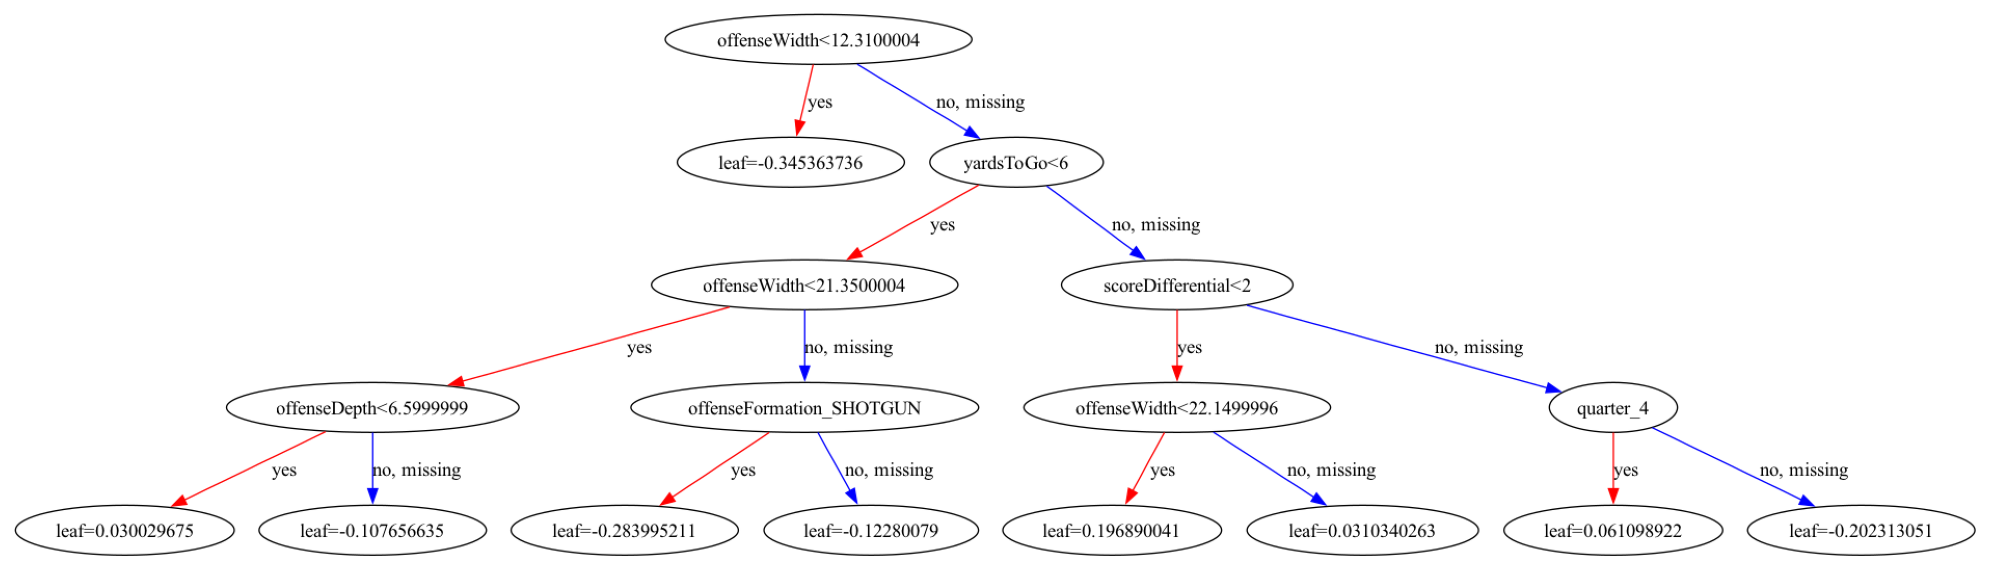

Saved tree visualization to xgb_tree_0.png


/opt/anaconda3/lib/python3.13/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


In [10]:
#The XGboost performed the best on the test set. 

#Visualizing the XGboost tree

import matplotlib.pyplot as plt
from xgboost import plot_tree

# Visualize the first boosted tree (tree index 0) from the selected XGBoost model
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(best_xgb_model, num_trees=0, ax=ax)
plt.tight_layout()
plt.show()

# Optional: render with graphviz for a cleaner, higher-resolution view
import xgboost as xgb
graph = xgb.to_graphviz(best_xgb_model, num_trees=0)
graph.render("xgb_tree_0", format="png", cleanup=True)  # saves xgb_tree_0.png
print("Saved tree visualization to xgb_tree_0.png")

#XGboost did the best here; I guess it probably found that the biggest independent determinant was offense width; 

ValueError: Failed to parse model text dump.